# Find FOVs that are good examples of nucleus staining with contamination and not

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

np.random.seed(0)  # Set seed for reproducibility

In [2]:
# path to the directory containing the profiles
profiles_dir = pathlib.Path(
    "/media/18tbdrive/1.Github_Repositories/nf1_schwann_cell_painting_data/3.processing_features/data/cleaned_profiles"
)

# read in the Plate 3 profile to find example FOVs
plate3_profile = pd.read_parquet(profiles_dir / "Plate_3_cleaned.parquet")

# display the first few rows of the profile
print(plate3_profile.shape)
plate3_profile.head()

(16093, 2321)


,Metadata_ImageNumber,Image_Metadata_Plate,Metadata_number_of_singlecells,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Image_FileName_CY5,...,Nuclei_Texture_Variance_DAPI_3_02_256,Nuclei_Texture_Variance_DAPI_3_03_256,Nuclei_Texture_Variance_GFP_3_00_256,Nuclei_Texture_Variance_GFP_3_01_256,Nuclei_Texture_Variance_GFP_3_02_256,Nuclei_Texture_Variance_GFP_3_03_256,Nuclei_Texture_Variance_RFP_3_00_256,Nuclei_Texture_Variance_RFP_3_01_256,Nuclei_Texture_Variance_RFP_3_02_256,Nuclei_Texture_Variance_RFP_3_03_256
1,5,Plate_3,84,14,B10,1,1,2,2,B10_01_3_14_CY5_001_illumcorrect.tiff,...,674.346209,687.648994,38.764372,40.170070,40.270733,37.789788,101.849116,99.378570,99.875012,98.784846
2,12,Plate_3,84,20,B10,1,1,2,2,B10_01_3_20_CY5_001_illumcorrect.tiff,...,1566.205750,1486.305372,279.656989,270.323458,300.199086,289.428542,189.134603,192.120194,188.116851,187.663065
3,13,Plate_3,84,21,B10,1,1,2,2,B10_01_3_21_CY5_001_illumcorrect.tiff,...,544.841379,546.635939,35.728497,37.452466,34.925836,34.609601,84.199793,86.931665,85.634432,82.349088
4,14,Plate_3,84,22,B10,1,1,2,2,B10_01_3_22_CY5_001_illumcorrect.tiff,...,1001.824339,979.699936,85.783028,82.215142,84.944425,100.984105,226.980762,230.125834,230.609025,226.963522
5,16,Plate_3,84,24,B10,1,1,2,2,B10_01_3_24_CY5_001_illumcorrect.tiff,...,807.698791,820.489413,32.134121,32.495775,34.768930,33.524842,115.094842,109.207702,107.667167,103.572729


In [3]:
# select specific wells to take FOVs from
selected_wells = ["E7", "B8", "C11", "G4"]

# filter the profile for the selected wells
filtered_profile = plate3_profile[
    plate3_profile["Image_Metadata_Well"].isin(selected_wells)
]

# display the filtered profile
filtered_profile.head()

,Metadata_ImageNumber,Image_Metadata_Plate,Metadata_number_of_singlecells,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Image_FileName_CY5,...,Nuclei_Texture_Variance_DAPI_3_02_256,Nuclei_Texture_Variance_DAPI_3_03_256,Nuclei_Texture_Variance_GFP_3_00_256,Nuclei_Texture_Variance_GFP_3_01_256,Nuclei_Texture_Variance_GFP_3_02_256,Nuclei_Texture_Variance_GFP_3_03_256,Nuclei_Texture_Variance_RFP_3_00_256,Nuclei_Texture_Variance_RFP_3_01_256,Nuclei_Texture_Variance_RFP_3_02_256,Nuclei_Texture_Variance_RFP_3_03_256
51,237,Plate_3,796,15,B8,1,1,2,2,B8_01_3_15_CY5_001_illumcorrect.tiff,...,294.067008,292.995333,91.396109,89.781458,85.029784,80.955246,148.564152,147.658470,148.741266,151.937196
53,241,Plate_3,796,19,B8,1,1,2,2,B8_01_3_19_CY5_001_illumcorrect.tiff,...,641.844611,615.728744,42.977080,39.213954,40.897009,39.369790,46.973393,45.583262,45.745771,46.355989
54,246,Plate_3,796,23,B8,1,1,2,2,B8_01_3_23_CY5_001_illumcorrect.tiff,...,764.617866,745.465180,101.304822,101.816705,116.133535,107.911746,345.127093,339.088213,339.959116,336.286553
55,247,Plate_3,796,24,B8,1,1,2,2,B8_01_3_24_CY5_001_illumcorrect.tiff,...,956.012660,960.652704,386.984603,383.068869,413.092556,385.509979,272.174848,268.231556,267.466955,268.150399
56,248,Plate_3,796,25,B8,1,1,2,2,B8_01_3_25_CY5_001_illumcorrect.tiff,...,356.312018,354.987267,211.586852,217.380035,211.257454,215.953665,60.085306,55.169076,59.221378,66.087646


In [ ]:
# For each well, randomly select one Image_Metadata_Site
fovs = []
for well in selected_wells:
    well_rows = filtered_profile[
        filtered_profile["Image_Metadata_Well"].astype(str) == str(well)
    ]
    # Filter for rows with at least 10 cells
    cell_count_threshold = 10
    well_rows = well_rows[
        well_rows["Metadata_number_of_singlecells"] >= cell_count_threshold
    ]
    if not well_rows.empty:
        site = np.random.choice(well_rows["Image_Metadata_Site"].unique())
        cell_row = well_rows[well_rows["Image_Metadata_Site"] == site].iloc[0]
        fovs.append(
            {
                "well": well,
                "site": site,
                "Image_PathName_DAPI": cell_row["Image_PathName_DAPI"],
                "Image_FileName_DAPI": cell_row["Image_FileName_DAPI"],
            }
        )

# Print the selected FOVs
for fov in fovs:
    print(
        f"Well: {fov['well']}, Site: {fov['site']}, "
        f"DAPI Path: {fov['Image_PathName_DAPI']}, "
        f"DAPI File: {fov['Image_FileName_DAPI']}"
    )

Well: E7, Site: 25, DAPI Path: /home/jenna/nf1_cellpainting_data/1.cellprofiler_ic/Corrected_Images/Corrected_Plate_3, DAPI File: E7_01_1_25_DAPI_001_illumcorrect.tiff
Well: B8, Site: 20, DAPI Path: /home/jenna/nf1_cellpainting_data/1.cellprofiler_ic/Corrected_Images/Corrected_Plate_3, DAPI File: B8_01_1_20_DAPI_001_illumcorrect.tiff
Well: C11, Site: 21, DAPI Path: /home/jenna/nf1_cellpainting_data/1.cellprofiler_ic/Corrected_Images/Corrected_Plate_3, DAPI File: C11_01_1_21_DAPI_001_illumcorrect.tiff
Well: G4, Site: 14, DAPI Path: /home/jenna/nf1_cellpainting_data/1.cellprofiler_ic/Corrected_Images/Corrected_Plate_3, DAPI File: G4_01_1_14_DAPI_001_illumcorrect.tiff


In [5]:
fovs_df = pd.DataFrame(fovs)
fovs_df.head()

,well,site,Image_PathName_DAPI,Image_FileName_DAPI
0,E7,25,/home/jenna/nf1_cellpainting_data/1.cellprofil...,E7_01_1_25_DAPI_001_illumcorrect.tiff
1,B8,20,/home/jenna/nf1_cellpainting_data/1.cellprofil...,B8_01_1_20_DAPI_001_illumcorrect.tiff
2,C11,21,/home/jenna/nf1_cellpainting_data/1.cellprofil...,C11_01_1_21_DAPI_001_illumcorrect.tiff
3,G4,14,/home/jenna/nf1_cellpainting_data/1.cellprofil...,G4_01_1_14_DAPI_001_illumcorrect.tiff


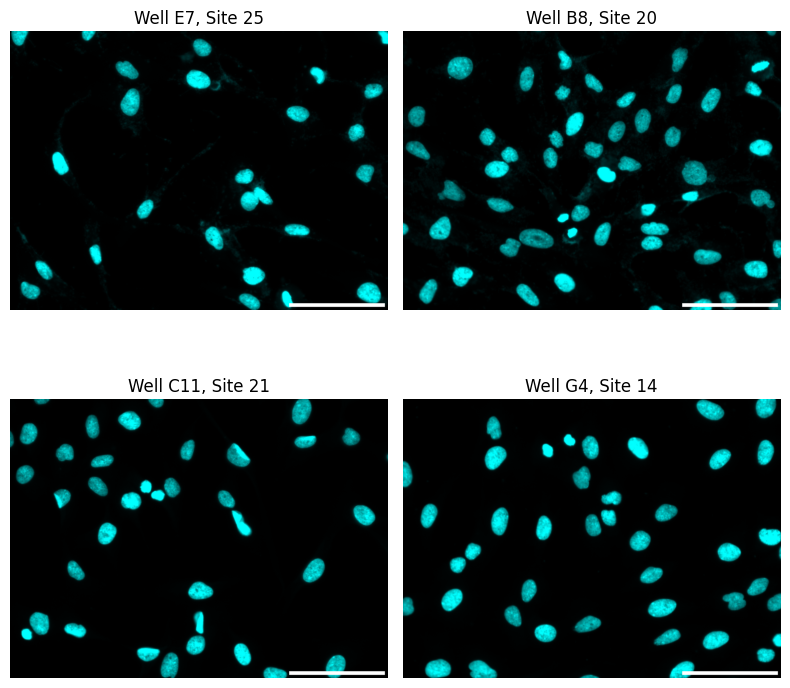

In [ ]:
# Set pixel-to-micron conversion
microns_per_pixel = 3.1065
scalebar_length_um = 100
scalebar_length_px = int(scalebar_length_um * microns_per_pixel)

# Plot only the DAPI image for each FOV in well_rows in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, (_, fov_row) in zip(axes, fovs_df.iterrows()):
    img_path = fov_row["Image_PathName_DAPI"]
    img_file = fov_row["Image_FileName_DAPI"]
    full_path = pathlib.Path(img_path) / img_file

    img = Image.open(full_path)
    img_arr = np.array(img)

    GRAYSCALE_DIM = 2
    if img_arr.ndim == GRAYSCALE_DIM:  # grayscale
        img_arr = img_arr.astype(np.float32)

        # Contrast stretch using 1st and 99th percentiles
        p1, p99 = np.percentile(img_arr, (1, 99))
        img_arr = np.clip(img_arr, p1, p99)
        img_arr = 255 * (img_arr - p1) / (p99 - p1 + 1e-5)
        img_arr = img_arr.astype(np.uint8)

        cyan_img = np.zeros((*img_arr.shape, 3), dtype=np.uint8)
        cyan_img[..., 1] = img_arr  # G
        cyan_img[..., 2] = img_arr  # B

        # Add scale bar directly to image
        bar_height = 12  # in pixels (thickness of the bar)
        x_offset = 10
        y_offset = 10

        x_start = img_arr.shape[1] - scalebar_length_px - x_offset
        y_start = img_arr.shape[0] - bar_height - y_offset
        x_end = x_start + scalebar_length_px
        y_end = y_start + bar_height

        cyan_img[y_start:y_end, x_start:x_end] = 255  # white bar

        ax.imshow(cyan_img)
    else:
        ax.imshow(img)

    # Save the displayed image as PNG
    save_name = f"Well_{fov_row['well']}_Site_{fov_row['site']}.png"
    fov_dir = pathlib.Path("./panelA_FOVs")
    fov_dir.mkdir(exist_ok=True)
    if img_arr.ndim == GRAYSCALE_DIM:
        Image.fromarray(cyan_img).save(f"{fov_dir}/{save_name}")

    ax.set_title(f"Well {fov_row['well']}, Site {fov_row['site']}")
    ax.axis("off")

plt.tight_layout()
plt.show()